In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
#Load Returns
PROCESSED_DIR = Path("../data/processed")
returns = pd.read_csv(PROCESSED_DIR / "returns_daily.csv", index_col="Date", parse_dates=True)

In [3]:
tickers = returns.columns.tolist()
trading_days = 252

#Compute Annualized inputs
mu = returns.mean() * trading_days                 # expected annual return vector
cov = returns.cov() * trading_days                 # annualized covariance matrix
corr = returns.corr()

mu, cov.shape, corr.shape

(NVDA    0.647818
 MSFT    0.273520
 JNJ     0.084805
 JPM     0.191236
 RTX     0.102158
 V       0.194904
 dtype: float64,
 (6, 6),
 (6, 6))

In [4]:
#Monte Carlo Random Portfolios Simulation
def simulate_portfolios(mu, cov, n_portfolios=20000, rf=0.0, seed=42):
    np.random.seed(seed)
    tickers = mu.index.tolist()
    n_assets = len(tickers)

    # Random weights that sum to 1 (Dirichlet is clean for this)
    weights = np.random.dirichlet(np.ones(n_assets), size=n_portfolios)

    # Portfolio expected return
    port_ret = weights @ mu.values

    # Portfolio volatility: sqrt(w^T Σ w)
    port_var = np.einsum('ij,jk,ik->i', weights, cov.values, weights)
    port_vol = np.sqrt(port_var)

    sharpe = (port_ret - rf) / np.where(port_vol == 0, np.nan, port_vol)

    sim = pd.DataFrame(weights, columns=[f"w_{t}" for t in tickers])
    sim["exp_return"] = port_ret
    sim["volatility"] = port_vol
    sim["sharpe"] = sharpe
    return sim

In [5]:
sim = simulate_portfolios(mu, cov, n_portfolios=30000, rf=0.0, seed=7)
sim.head()

,w_NVDA,w_MSFT,w_JNJ,w_JPM,w_RTX,w_V,exp_return,volatility,sharpe
0,0.009867,0.188161,0.071719,0.159778,0.474359,0.096117,0.161688,0.204361,0.791190
1,0.153136,0.016467,0.068834,0.152590,0.250392,0.358580,0.234195,0.213786,1.095466
2,0.116036,0.016505,0.082240,0.581551,0.058076,0.145593,0.232182,0.223497,1.038858
3,0.348759,0.003285,0.119569,0.390674,0.034106,0.103607,0.335360,0.250810,1.337104
4,0.374351,0.022307,0.115679,0.216642,0.172585,0.098437,0.336669,0.251554,1.338360


In [6]:
# Max Sharpe (rf=0 for now)
max_sharpe = sim.loc[sim["sharpe"].idxmax()]

# Minimum volatility
min_vol = sim.loc[sim["volatility"].idxmin()]

# Equal-weight baseline
w_eq = np.ones(len(tickers)) / len(tickers)
eq_ret = float(w_eq @ mu.values)
eq_vol = float(np.sqrt(w_eq @ cov.values @ w_eq))
eq_sharpe = eq_ret / eq_vol if eq_vol != 0 else np.nan

In [7]:
max_sharpe

w_NVDA        0.533496
w_MSFT        0.157601
w_JNJ         0.169204
w_JPM         0.098786
w_RTX         0.000871
w_V           0.040041
exp_return    0.429850
volatility    0.302408
sharpe        1.421422
Name: 28535, dtype: float64

In [8]:
min_vol

w_NVDA        0.005297
w_MSFT        0.093683
w_JNJ         0.656863
w_JPM         0.072685
w_RTX         0.090960
w_V           0.080511
exp_return    0.123646
volatility    0.163817
sharpe        0.754780
Name: 24191, dtype: float64

In [9]:
(eq_ret, eq_vol, eq_sharpe)

(0.24907376299157935, 0.204879521318506, 1.21570843873834)

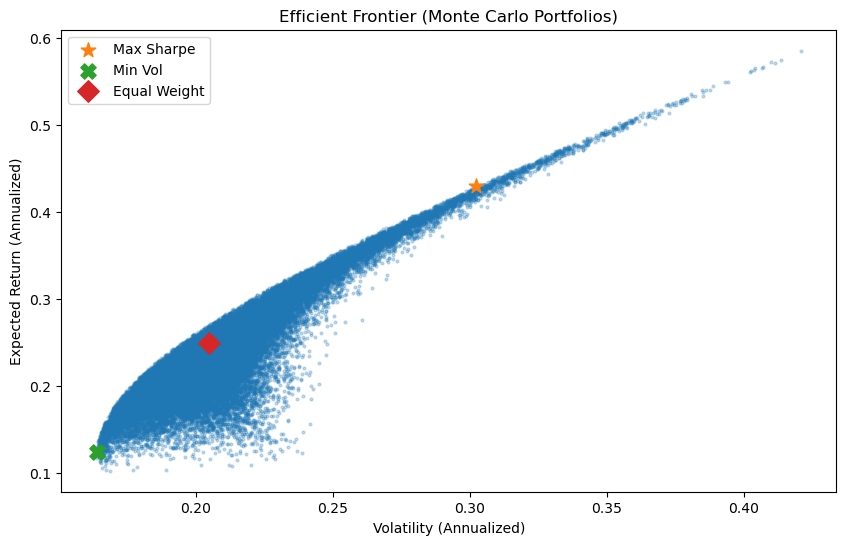

In [10]:
plt.figure(figsize=(10,6))
plt.scatter(sim["volatility"], sim["exp_return"], s=4, alpha=0.25)

plt.scatter(max_sharpe["volatility"], max_sharpe["exp_return"], s=120, marker="*", label="Max Sharpe")
plt.scatter(min_vol["volatility"], min_vol["exp_return"], s=120, marker="X", label="Min Vol")
plt.scatter(eq_vol, eq_ret, s=120, marker="D", label="Equal Weight")

plt.xlabel("Volatility (Annualized)")
plt.ylabel("Expected Return (Annualized)")
plt.title("Efficient Frontier (Monte Carlo Portfolios)")
plt.legend()
plt.show()

In [11]:
def show_weights(port_row, tickers):
    w = port_row[[f"w_{t}" for t in tickers]].copy()
    w.index = tickers
    return (w.sort_values(ascending=False) * 100).round(2)

print("Max Sharpe Portfolio (%)")
display(show_weights(max_sharpe, tickers))

print("Min Vol Portfolio (%)")
display(show_weights(min_vol, tickers))

print("Equal Weight Portfolio (%)")
display(pd.Series((w_eq*100).round(2), index=tickers).sort_values(ascending=False))

Max Sharpe Portfolio (%)


NVDA    53.35
JNJ     16.92
MSFT    15.76
JPM      9.88
V        4.00
RTX      0.09
Name: 28535, dtype: float64

Min Vol Portfolio (%)


JNJ     65.69
MSFT     9.37
RTX      9.10
V        8.05
JPM      7.27
NVDA     0.53
Name: 24191, dtype: float64

Equal Weight Portfolio (%)


NVDA    16.67
MSFT    16.67
JNJ     16.67
JPM     16.67
RTX     16.67
V       16.67
dtype: float64

In [12]:
#Lowest Average Correlation
avg_corr = corr.apply(lambda col: (col.drop(col.name)).mean())
avg_corr.sort_values()

JNJ     0.353596
NVDA    0.365677
RTX     0.434284
JPM     0.467293
MSFT    0.479715
V       0.523024
dtype: float64

In [13]:
#Marginal contribution to Risk (MCR) under equal weights
w = w_eq
port_vol = np.sqrt(w.T @ cov.values @ w)

# MCR_i = (Σw)_i / σ_p
mcr = (cov.values @ w) / port_vol

mcr_series = pd.Series(mcr, index=tickers).sort_values()
mcr_series

JNJ     0.096840
RTX     0.178565
V       0.194305
JPM     0.195581
MSFT    0.209695
NVDA    0.354291
dtype: float64

In [14]:
#Crisis Correlation check
stress = returns.loc["2020-02-01":"2020-06-30"]
calm = returns.loc["2019-01-01":"2019-12-31"]

stress_corr = stress.corr()
calm_corr = calm.corr()

(stress_corr - calm_corr).round(2)

,NVDA,MSFT,JNJ,JPM,RTX,V
NVDA,0.00,0.32,0.45,0.16,0.13,0.31
MSFT,0.32,0.00,0.46,0.29,0.03,0.14
JNJ,0.45,0.46,0.00,0.42,0.28,0.48
JPM,0.16,0.29,0.42,0.00,0.18,0.43
RTX,0.13,0.03,0.28,0.18,0.00,0.29
V,0.31,0.14,0.48,0.43,0.29,0.00


## 5.5 The Constrained Frontier

In [15]:
#Re-simulate w/ Risk-Free Rate
RF = 0.03  # 3% annual risk-free rate

sim_rf = simulate_portfolios(mu, cov, n_portfolios=30000, rf=RF, seed=7)

In [16]:
max_sharpe_rf = sim_rf.loc[sim_rf["sharpe"].idxmax()]
max_sharpe_rf

w_NVDA        0.698407
w_MSFT        0.108508
w_JNJ         0.052157
w_JPM         0.112568
w_RTX         0.000387
w_V           0.027972
exp_return    0.513562
volatility    0.363267
sharpe        1.331147
Name: 4467, dtype: float64

In [17]:
#Imposing 40% Weight Cap
CAP = 0.40

weight_cols = [col for col in sim_rf.columns if col.startswith("w_")]

sim_constrained = sim_rf[
    (sim_rf[weight_cols] <= CAP).all(axis=1)
].copy()

len(sim_constrained)

16169

In [18]:
#Extracting Constrained Max Sharpe & Min Vol
max_sharpe_constrained = sim_constrained.loc[sim_constrained["sharpe"].idxmax()]
min_vol_constrained = sim_constrained.loc[sim_constrained["volatility"].idxmin()]

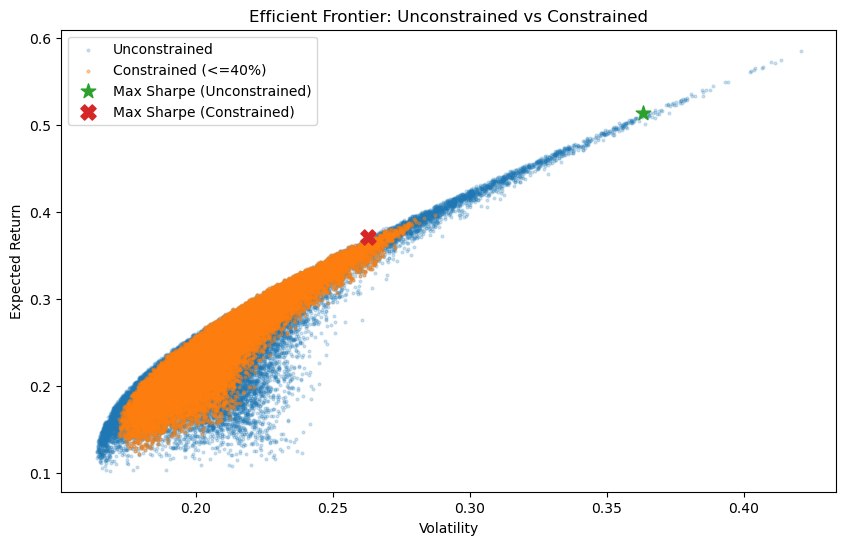

In [19]:
#Plot Constrained vs Unconstrained
plt.figure(figsize=(10,6))

plt.scatter(sim_rf["volatility"], sim_rf["exp_return"], s=4, alpha=0.2, label="Unconstrained")
plt.scatter(sim_constrained["volatility"], sim_constrained["exp_return"], s=4, alpha=0.4, label="Constrained (<=40%)")

plt.scatter(max_sharpe_rf["volatility"], max_sharpe_rf["exp_return"], s=120, marker="*", label="Max Sharpe (Unconstrained)")
plt.scatter(max_sharpe_constrained["volatility"], max_sharpe_constrained["exp_return"], s=120, marker="X", label="Max Sharpe (Constrained)")

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier: Unconstrained vs Constrained")
plt.legend()

# Save to the relative path
# '../' goes up to 'project/', then into 'reports/figures/'
plt.savefig('../reports/figures/frontier_uncon_vs_con.png', dpi=300, bbox_inches='tight', facecolor = 'white')

plt.show()

In [20]:
#Compare Weights
print("Unconstrained Max Sharpe (%)")
display(show_weights(max_sharpe_rf, tickers))

print("Constrained Max Sharpe (%)")
display(show_weights(max_sharpe_constrained, tickers))

Unconstrained Max Sharpe (%)


NVDA    69.84
JPM     11.26
MSFT    10.85
JNJ      5.22
V        2.80
RTX      0.04
Name: 4467, dtype: float64

Constrained Max Sharpe (%)


NVDA    39.91
MSFT    24.60
JNJ     21.31
JPM     13.20
V        0.88
RTX      0.10
Name: 23575, dtype: float64

In [21]:
max_sharpe_constrained

w_NVDA        0.399124
w_MSFT        0.245992
w_JNJ         0.213074
w_JPM         0.132025
w_RTX         0.000976
w_V           0.008809
exp_return    0.370978
volatility    0.262808
sharpe        1.297440
Name: 23575, dtype: float64

In [22]:
max_sharpe_rf

w_NVDA        0.698407
w_MSFT        0.108508
w_JNJ         0.052157
w_JPM         0.112568
w_RTX         0.000387
w_V           0.027972
exp_return    0.513562
volatility    0.363267
sharpe        1.331147
Name: 4467, dtype: float64

In [23]:
min_vol_constrained

w_NVDA        0.001339
w_MSFT        0.112916
w_JNJ         0.385579
w_JPM         0.105910
w_RTX         0.169079
w_V           0.225177
exp_return    0.145866
volatility    0.171842
sharpe        0.674257
Name: 16755, dtype: float64